In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm, colors

In [3]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc, classification_report)

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [5]:
DATA_PATH = r"C:\Users\KIIT\Downloads\tsunami\earthquake_data_tsunami.csv"
df = pd.read_csv(DATA_PATH)
print("Records:", len(df))
display(df.head())

Records: 782


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


In [6]:
print("\nData types / nulls:")
print(df.info())


Data types / nulls:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.5 KB
None


In [7]:
print("\nTarget distribution:")
print(df['tsunami'].value_counts(normalize=False))


Target distribution:
tsunami
0    478
1    304
Name: count, dtype: int64


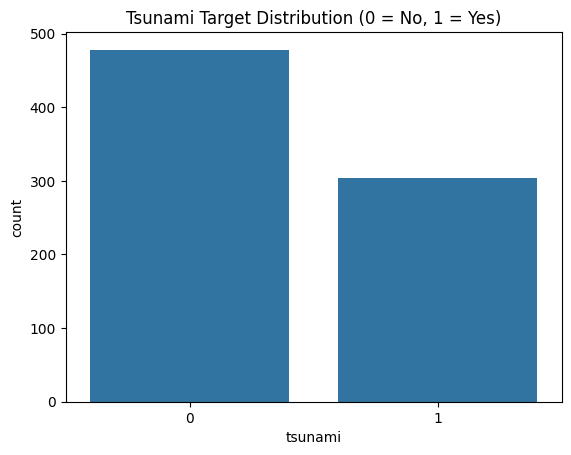

In [8]:
sns.countplot(data=df, x='tsunami')
plt.title("Tsunami Target Distribution (0 = No, 1 = Yes)")
plt.show()

In [9]:
display(df.describe())

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199,2012.280051,6.563939,0.388747
std,0.445514,3.169939,1.462724,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886,6.099439,3.507866,0.487778
min,6.500000,0.000000,1.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000,2001.000000,1.000000,0.000000
25%,6.600000,0.000000,5.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050,2007.000000,3.250000,0.000000
50%,6.800000,5.000000,6.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000,2013.000000,7.000000,0.000000
75%,7.100000,7.000000,7.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000,2017.000000,10.000000,1.000000
max,9.100000,9.000000,9.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000,2022.000000,12.000000,1.000000


In [10]:
# Quantile transform some skewed numeric columns
qt = QuantileTransformer(output_distribution='normal', random_state=42)
cols_to_qt = ['nst', 'dmin', 'gap', 'depth', 'sig']
df[cols_to_qt] = qt.fit_transform(df[cols_to_qt])

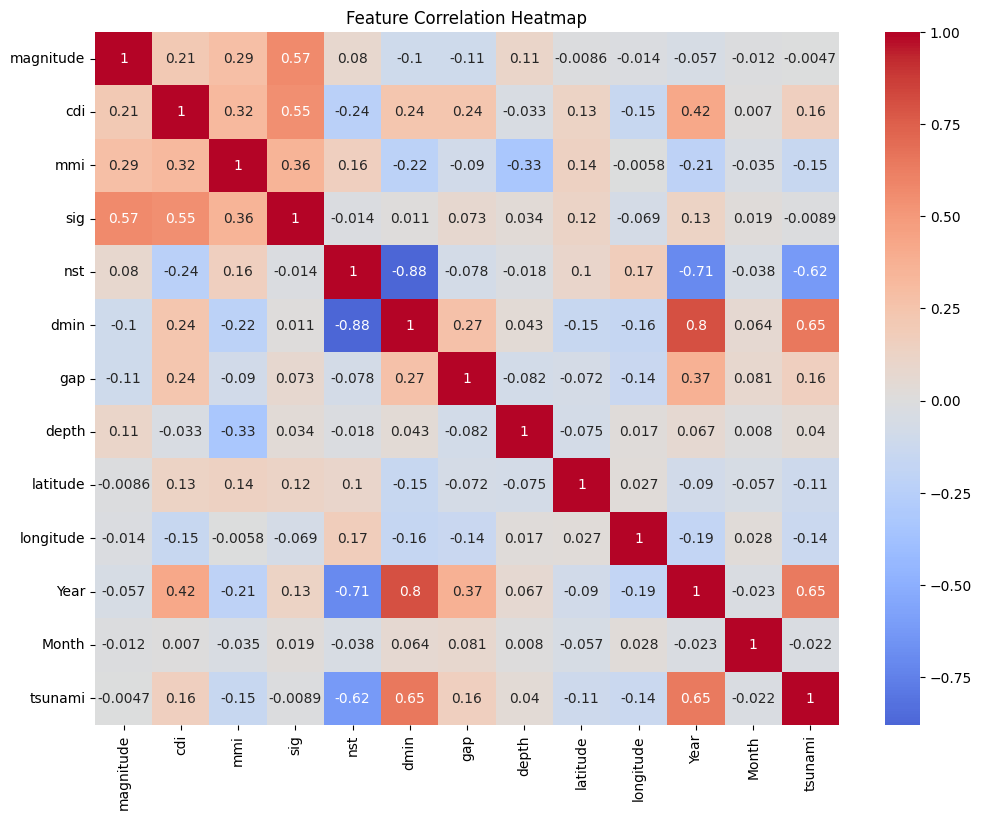

In [11]:
# Correlation heatmap
plt.figure(figsize=(12,9))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [12]:
class SphericalRBF(BaseEstimator, TransformerMixin):
#   Transformer that:
#   - Converts (latitude, longitude) -> 3D unit vectors on the sphere
#   - Fits KMeans on unit vectors to obtain cluster centers on sphere
#   - Transforms each coordinate into RBF similarities to each center using angular distance (great-circle)
#    Returns an array with shape (n_samples, n_clusters)

    def __init__(self, n_clusters=5, gamma="auto", random_state=42):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def _to_unit(self, lat_arr, lon_arr):
        # lat_arr, lon_arr: arrays in degrees
        lat = np.radians(lat_arr)
        lon = np.radians(lon_arr)
        x = np.cos(lat) * np.cos(lon)
        y = np.cos(lat) * np.sin(lon)
        z = np.sin(lat)
        return np.vstack([x, y, z]).T

    def fit(self, X, y=None, sample_weight=None):
        # X expected as DataFrame-like with columns [latitude, longitude] or [lat, lon]
        X_arr = np.array(X)
        U = self._to_unit(X_arr[:, 0], X_arr[:, 1])
        self.kmeans_ = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init="auto").fit(U, sample_weight=sample_weight)
        dot = U @ self.kmeans_.cluster_centers_.T
        ang = np.arccos(np.clip(dot, -1.0, 1.0))
        med = np.median(ang[ang > 0]) if np.any(ang > 0) else 0.1
        if self.gamma == "auto":
            self.gamma_ = 1.0 / (2 * med**2) if med > 0 else 1.0
        else:
            self.gamma_ = float(self.gamma)
        return self

    def transform(self, X):
        X_arr = np.array(X)
        U = self._to_unit(X_arr[:, 0], X_arr[:, 1])
        dot = U @ self.kmeans_.cluster_centers_.T
        ang = np.arccos(np.clip(dot, -1.0, 1.0))
        return np.exp(-self.gamma_ * ang**2)

    def get_feature_names_out(self, names=None):
        return np.array([f"geo_cluster_{i}" for i in range(self.n_clusters)])

In [13]:
# 3. Preprocessing pipeline
geo_transformer = SphericalRBF(n_clusters=6, gamma="auto", random_state=42)

num_features = ['magnitude','cdi','mmi','sig','nst','dmin','gap','depth','Year','Month']
geo_cols = ['latitude','longitude']

preprocessor = ColumnTransformer(transformers=[
    ("geo", geo_transformer, geo_cols),
    ("num", StandardScaler(), num_features)
], remainder='drop', verbose_feature_names_out=False)

# Build a pipeline that returns transformed feature names as well (we'll use it later)
def build_pipeline_with_model(model):
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

In [14]:
# 4. Feature matrix and split
target = 'tsunami'
features = [c for c in df.columns if c != target]
X = df[features].copy()
y = df[target].copy()
# Stratified split (preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train / Test sizes:", X_train.shape, X_test.shape)

Train / Test sizes: (625, 12) (157, 12)


In [15]:
!pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
from xgboost import XGBClassifier
# 5. Define model set
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5
    )
}
print("Models to run:", list(models.keys()))

Models to run: ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']


In [17]:
# 6. Train & evaluate each model (single train/test + cross-val)
results = []
fitted_models = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n--- Training: {name} ---")
    pipeline = build_pipeline_with_model(model)
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline

    #Predictions for both train and test
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    try:
        y_proba = pipeline.predict_proba(X_test)[:, 1]
    except:
        # fallback if predict_proba missing
        if hasattr(pipeline.named_steps['model'], "decision_function"):
            df_scores = pipeline.decision_function(X_test)
            y_proba = (df_scores - df_scores.min()) / (df_scores.max() - df_scores.min() + 1e-12)
        else:
            y_proba = np.zeros_like(y_test_pred)

    #Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_proba) if len(np.unique(y_proba)) > 1 else np.nan

    #Cross-validation
    try:
        cv_scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='accuracy', n_jobs=-1)
        cv_mean = cv_scores.mean()
    except Exception as e:
        cv_mean = np.nan

    results.append({
        "Model": name,
        "Train_Accuracy": train_acc,
        "CV_Accuracy": cv_mean,
        "Test_Accuracy": test_acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": roc
    })

    print(f"Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f} | "
          f"Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | ROC_AUC: {roc:.4f}")



--- Training: Decision Tree ---
Train Accuracy: 1.0000 | Test Accuracy: 0.8790 | Precision: 0.8500 | Recall: 0.8361 | F1: 0.8430 | ROC_AUC: 0.8712

--- Training: Random Forest ---
Train Accuracy: 1.0000 | Test Accuracy: 0.9172 | Precision: 0.8636 | Recall: 0.9344 | F1: 0.8976 | ROC_AUC: 0.9636

--- Training: Gradient Boosting ---
Train Accuracy: 1.0000 | Test Accuracy: 0.9236 | Precision: 0.8657 | Recall: 0.9508 | F1: 0.9062 | ROC_AUC: 0.9664

--- Training: XGBoost ---
Train Accuracy: 1.0000 | Test Accuracy: 0.9108 | Precision: 0.8615 | Recall: 0.9180 | F1: 0.8889 | ROC_AUC: 0.9623


In [18]:
results_df = pd.DataFrame(results).sort_values(by="ROC_AUC", ascending=False).reset_index(drop=True)
display(results_df)

,Model,Train_Accuracy,CV_Accuracy,Test_Accuracy,Precision,Recall,F1,ROC_AUC
0,Gradient Boosting,1.0,0.9232,0.923567,0.865672,0.950820,0.906250,0.966359
1,Random Forest,1.0,0.9280,0.917197,0.863636,0.934426,0.897638,0.963627
2,XGBoost,1.0,0.9248,0.910828,0.861538,0.918033,0.888889,0.962261
3,Decision Tree,1.0,0.9104,0.878981,0.850000,0.836066,0.842975,0.871158


In [19]:
# 7. Show confusion matrix and ROC for the top models (and the four specified models)
def plot_confusion_and_roc(name, pipeline, X_test=X_test, y_test=y_test):
    y_pred = pipeline.predict(X_test)
    try:
        y_proba = pipeline.predict_proba(X_test)[:, 1]
    except:
        if hasattr(pipeline.named_steps['model'], "decision_function"):
            df_scores = pipeline.decision_function(X_test)
            y_proba = (df_scores - df_scores.min()) / (df_scores.max() - df_scores.min() + 1e-12)
        else:
            y_proba = np.zeros_like(y_pred)

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # ROC
    if len(np.unique(y_proba))>1:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
        plt.plot([0,1],[0,1],'--', color='gray')
        plt.title(f"ROC Curve — {name}")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()
    else:
        print("ROC curve unavailable (predict_proba/decision scores constant).")


Top model by ROC_AUC: Gradient Boosting


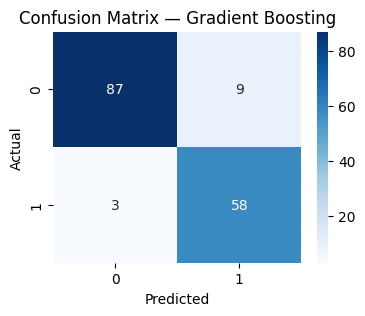

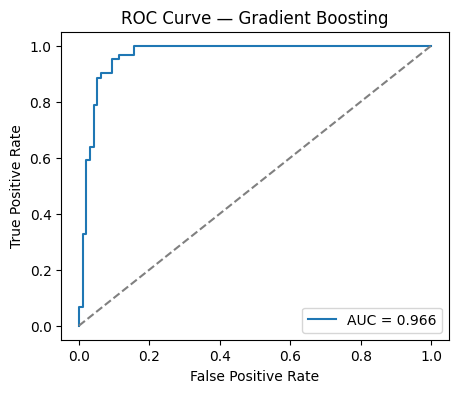

In [20]:
# Top model by ROC_AUC
top_model_name = results_df.iloc[0]["Model"]
print("Top model by ROC_AUC:", top_model_name)
plot_confusion_and_roc(top_model_name, fitted_models[top_model_name])



Details for: Gradient Boosting


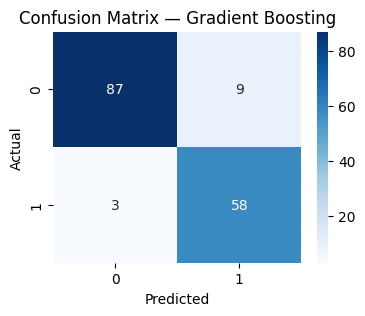

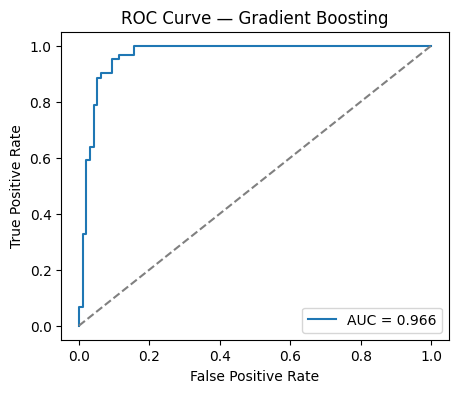


Details for: XGBoost


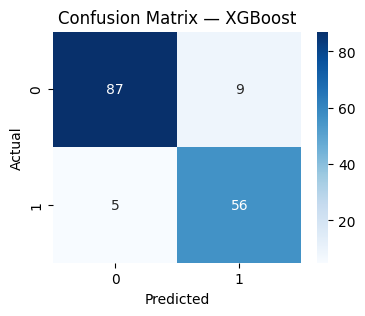

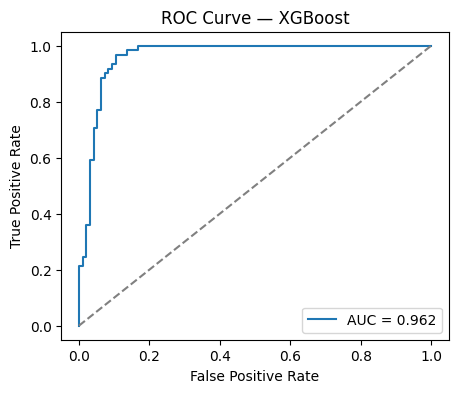


Details for: Random Forest


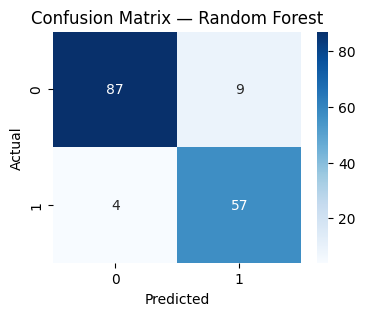

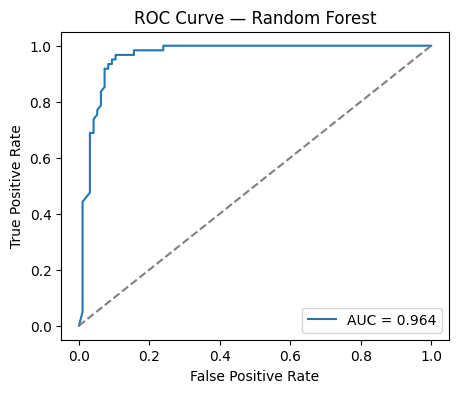


Details for: Decision Tree


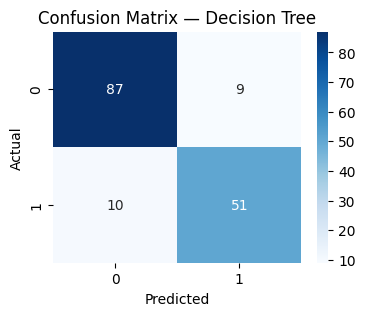

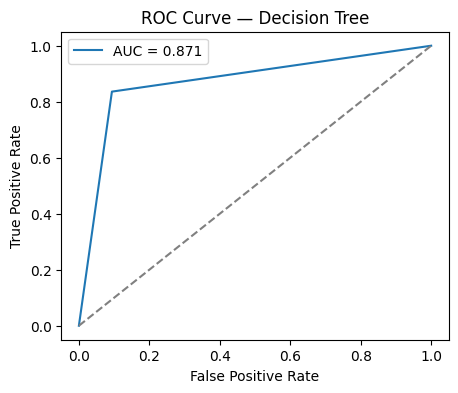

In [21]:
# Also plot the user-specified models (Decision Tree, Random Forest, Gradient Boosting, XGBoost if present)
requested = ["Gradient Boosting", "XGBoost", "Random Forest", "Decision Tree"]
for r in requested:
    if r in fitted_models:
        print("\nDetails for:", r)
        plot_confusion_and_roc(r, fitted_models[r])

In [22]:
def get_feature_names_from_preprocessor(preproc):
    """
    Returns names after ColumnTransformer:
    - geo -> geo_cluster_0..n
    - num -> original numeric feature names
    """
    names = []
    for name, trans, cols in preproc.transformers_:
        if name == 'geo':
            # Custom transformer (SphericalRBF or similar)
            out_names = trans.get_feature_names_out()
            names.extend(out_names.tolist())
        elif name == 'num':
            # StandardScaler or similar keeps same column names
            names.extend(cols)
    return names

Transformed feature count: 16
['geo_cluster_0', 'geo_cluster_1', 'geo_cluster_2', 'geo_cluster_3', 'geo_cluster_4', 'geo_cluster_5', 'magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth', 'Year', 'Month']


,Feature,Importance
0,Year,0.592122
1,geo_cluster_1,0.148714
2,geo_cluster_4,0.060126
3,geo_cluster_5,0.038001
4,geo_cluster_2,0.036093
5,geo_cluster_0,0.020042
6,magnitude,0.019904
7,dmin,0.018819
8,depth,0.014927
9,sig,0.013027


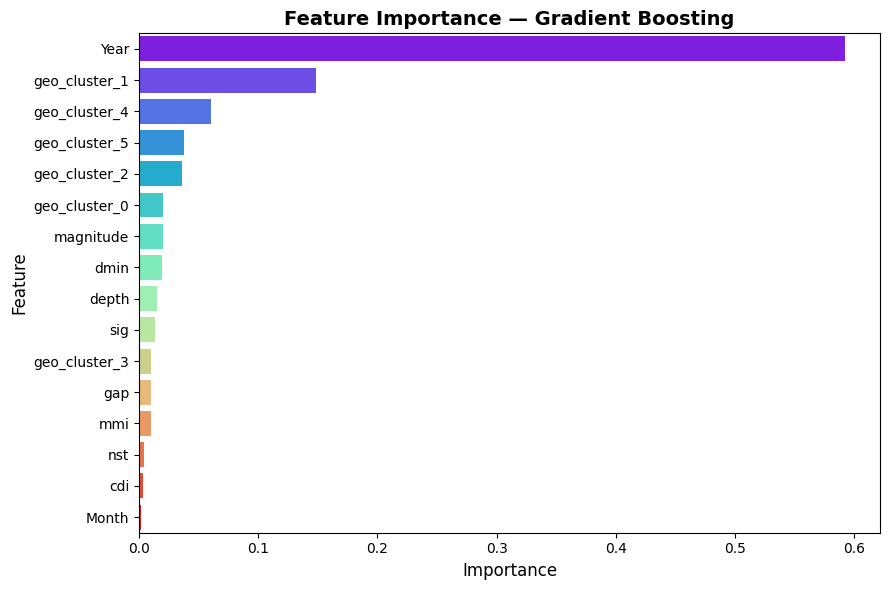

In [23]:
from matplotlib import cm

feature_names = get_feature_names_from_preprocessor(fitted_models[top_model_name].named_steps['preprocessor'])
print("Transformed feature count:", len(feature_names))
print(feature_names)

# If top model has feature_importances_, plot them
top_pipeline = fitted_models[top_model_name]
model_obj = top_pipeline.named_steps['model']

if hasattr(model_obj, "feature_importances_"):
    importances = model_obj.feature_importances_
    fi = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    fi = fi.sort_values(by="Importance", ascending=False).reset_index(drop=True)
    display(fi.head(20))
    
    colors = cm.rainbow(np.linspace(0, 1, len(fi.head(20))))
    plt.figure(figsize=(9,6))
    sns.barplot(
        data=fi.head(20),
        x="Importance",
        y="Feature",
        palette=colors
    )
    plt.title(f"Feature Importance — {top_model_name}", fontsize=14, fontweight='bold')
    plt.xlabel("Importance", fontsize=12)
    plt.ylabel("Feature", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print(f"Top model {top_model_name} doesn't support feature_importances_.")


In [24]:
# 9. Classification report for the top model
y_pred_top = top_pipeline.predict(X_test)
print(f"\nClassification report — {top_model_name}")
print(classification_report(y_test, y_pred_top, digits=4))


Classification report — Gradient Boosting
              precision    recall  f1-score   support

           0     0.9667    0.9062    0.9355        96
           1     0.8657    0.9508    0.9062        61

    accuracy                         0.9236       157
   macro avg     0.9162    0.9285    0.9209       157
weighted avg     0.9274    0.9236    0.9241       157



In [25]:
!pip install folium matplotlib scikit-learn branca numpy pandas


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import folium, numpy as np, pandas as pd
from sklearn.cluster import KMeans
from matplotlib import cm, colors
from branca.colormap import LinearColormap
data = pd.read_csv(r"C:\Users\KIIT\Downloads\tsunami\earthquake_data_tsunami.csv")

# Convert to 3D unit vectors
def to_unit(lat_deg, lon_deg):
    lat, lon = np.radians(lat_deg), np.radians(lon_deg)
    x = np.cos(lat)*np.cos(lon); y = np.cos(lat)*np.sin(lon); z = np.sin(lat)
    return np.c_[x, y, z]

def unit_to_latlon(C):
    x,y,z = C[:,0], C[:,1], C[:,2]
    lat = np.degrees(np.arctan2(z, np.sqrt(x*x+y*y)))
    lon = np.degrees(np.arctan2(y, x))
    return np.c_[lat, lon]

U = to_unit(data['latitude'].values, data['longitude'].values)
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto').fit(U)
centers_latlon = unit_to_latlon(kmeans.cluster_centers_)

clustered_data = data.copy()
clustered_data["cluster"] = kmeans.labels_

vmin, vmax = clustered_data["magnitude"].min(), clustered_data["magnitude"].max()
norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.get_cmap('RdBu_r')
mag_to_hex = lambda m: colors.rgb2hex(cmap(norm(m)))

m = folium.Map(location=[0, 0], zoom_start=2, tiles="CartoDB positron")

# Earthquakes
for _, row in clustered_data.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=float(row["magnitude"]) * 1.6,
        color="black",
        fill=True,
        fill_color=mag_to_hex(row["magnitude"]),
        fill_opacity=0.6,
        tooltip=f"Mag {row['magnitude']:.2f}"
    ).add_to(m)

# Cluster centers
for lat, lon in centers_latlon:
    folium.Marker(
        location=[float(lat), float(lon)],
        icon=folium.Icon(color="lightgray", icon="star", prefix="fa"),
        tooltip="Cluster Center"
    ).add_to(m)

LinearColormap(
    colors=[colors.rgb2hex(cmap(x)) for x in np.linspace(0,1,256)],
    vmin=vmin, vmax=vmax, caption="Magnitude"
).add_to(m)

m.save("earthquake_map.html")
m


In [27]:
import joblib

In [28]:
# 10. We will save the best model
best_model_filename = f"best_model_{top_model_name.replace(' ', '_')}.pkl"
joblib.dump(top_pipeline, best_model_filename)
print(f"Saved best model to: {best_model_filename}")


Saved best model to: best_model_Gradient_Boosting.pkl


In [29]:
#Summary table saved
results_df.to_csv("model_results_summary.csv", index=False)
print("Results summary saved to model_results_summary.csv")

Results summary saved to model_results_summary.csv
